In [ ]:
import pandas as pd

df = pd.read_csv('2019-Oct.csv')

df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


smartphone df 생성

In [3]:
smartphone_df = df[df['category_code'] == 'electronics.smartphone'].copy()

----------------------------

단순 view / purchase 파악 -> 브랜드 인기(노출도)

In [4]:
brand_view = (
    smartphone_df[smartphone_df['event_type'] == 'view']
    .groupby('brand')
    .size()
    .sort_values(ascending=False)
    .reset_index(name='view_count')
)

brand_view.head(10)

,brand,view_count
0,samsung,3386871
1,apple,2991772
2,xiaomi,2094234
3,huawei,940176
4,oppo,451449
5,meizu,152984
6,vivo,108180
7,honor,75499
8,nokia,69428
9,sony,66547


In [5]:
#비율
brand_view_ratio = brand_view.copy()
brand_view_ratio['ratio'] = brand_view_ratio['view_count'] / brand_view_ratio['view_count'].sum()

brand_view_ratio.head(10)

,brand,view_count,ratio
0,samsung,3386871,0.319565
1,apple,2991772,0.282286
2,xiaomi,2094234,0.197600
3,huawei,940176,0.088709
4,oppo,451449,0.042596
5,meizu,152984,0.014435
6,vivo,108180,0.010207
7,honor,75499,0.007124
8,nokia,69428,0.006551
9,sony,66547,0.006279


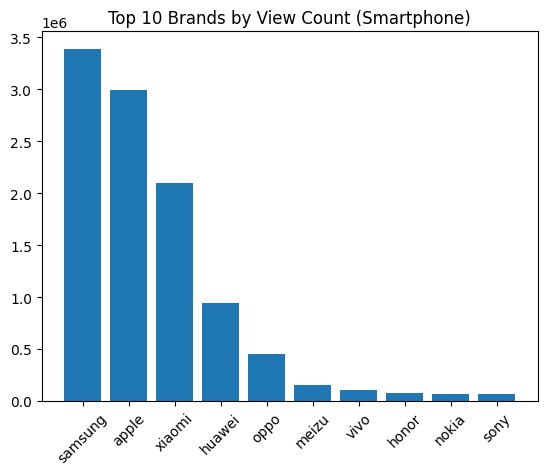

In [6]:
#시각화
import matplotlib.pyplot as plt

top10 = brand_view.head(10)

plt.figure()
plt.bar(top10['brand'], top10['view_count'])
plt.xticks(rotation=45)
plt.title('Top 10 Brands by View Count (Smartphone)')
plt.show()

In [7]:
brand_purchase = (
    smartphone_df[smartphone_df['event_type'] == 'purchase']
    .groupby('brand')
    .size()
    .sort_values(ascending=False)
    .reset_index(name='purchase_count')
)

brand_purchase.head(10)

,brand,purchase_count
0,samsung,143123
1,apple,115345
2,xiaomi,38776
3,huawei,21882
4,oppo,10891
5,vivo,2025
6,meizu,1686
7,honor,555
8,nokia,512
9,oneplus,509


In [8]:
brand_purchase_ratio = brand_purchase.copy()
brand_purchase_ratio['ratio'] = (
    brand_purchase_ratio['purchase_count'] / brand_purchase_ratio['purchase_count'].sum()
)

brand_purchase_ratio.head(10)

,brand,purchase_count,ratio
0,samsung,143123,0.423974
1,apple,115345,0.341687
2,xiaomi,38776,0.114866
3,huawei,21882,0.064821
4,oppo,10891,0.032262
5,vivo,2025,0.005999
6,meizu,1686,0.004994
7,honor,555,0.001644
8,nokia,512,0.001517
9,oneplus,509,0.001508


In [9]:
brand_revenue_detail = (
    smartphone_df[smartphone_df['event_type'] == 'purchase']
    .groupby('brand')
    .agg(
        revenue=('price', 'sum'),
        purchase_count=('price', 'count'),
        avg_price=('price', 'mean')
    )
    .sort_values(by='revenue', ascending=False)
    .reset_index()
)

brand_revenue_detail.head(10)

,brand,revenue,purchase_count,avg_price
0,apple,1.025490e+08,115345,889.063293
1,samsung,3.737366e+07,143123,261.129673
2,xiaomi,8.059770e+06,38776,207.854606
3,huawei,4.702812e+06,21882,214.916896
4,oppo,2.412960e+06,10891,221.555391
5,vivo,4.956786e+05,2025,244.779556
6,oneplus,3.510762e+05,509,689.737171
7,meizu,2.123246e+05,1686,125.933909
8,sony,1.675179e+05,494,339.105162
9,honor,1.374848e+05,555,247.720270


-------------------------------------------

세션 기준 브랜드 퍼널 분류

In [10]:
#정렬 + unknown처리
df = smartphone_df.sort_values(['user_session', 'event_time']).copy()
df['brand'] = df['brand'].fillna('unknown')

In [11]:
grouped = df.groupby(['user_session', 'brand'])

#grouped = df.groupby(['user_session', 'user_id', 'product_id', 'brand'])

In [12]:
result = []
for (session, brand), group in grouped:
    group = group.sort_values('event_time')  
    events = group['event_type'].tolist()

    
    # index 찾기
    view_idx = next((i for i, e in enumerate(events) if e == 'view'), None)
    cart_idx = next((i for i, e in enumerate(events) if e == 'cart'), None)
    purchase_idx = next((i for i, e in enumerate(events) if e == 'purchase'), None)
    
    has_view = view_idx is not None
    valid_view_cart = view_idx is not None and cart_idx is not None and view_idx < cart_idx
    valid_cart_purchase = cart_idx is not None and purchase_idx is not None and cart_idx < purchase_idx
    
    result.append([
        session, brand,
        has_view,
        valid_view_cart,
        valid_cart_purchase
    ])

funnel_df = pd.DataFrame(result, columns=[
    'user_session', 'brand',
    'view', 'view_to_cart', 'cart_to_purchase'
])

In [13]:
import numpy as np
import pandas as pd

# 브랜드별 퍼널 집계
brand_funnel = (
    funnel_df.groupby('brand')
    .agg(
        view_sessions=('view', 'sum'),
        view_to_cart_sessions=('view_to_cart', 'sum'),
        cart_to_purchase_sessions=('cart_to_purchase', 'sum')
    )
    .reset_index()
)

# 전환율 계산
brand_funnel['view_to_cart_rate'] = np.where(
    brand_funnel['view_sessions'] > 0,
    brand_funnel['view_to_cart_sessions'] / brand_funnel['view_sessions'],
    0
)

brand_funnel['cart_to_purchase_rate'] = np.where(
    brand_funnel['view_to_cart_sessions'] > 0,
    brand_funnel['cart_to_purchase_sessions'] / brand_funnel['view_to_cart_sessions'],
    0
)

brand_funnel['total_conversion_rate'] = np.where(
    brand_funnel['view_sessions'] > 0,
    brand_funnel['cart_to_purchase_sessions'] / brand_funnel['view_sessions'],
    0
)

# 이탈률
brand_funnel['drop_view_to_cart'] = 1 - brand_funnel['view_to_cart_rate']
brand_funnel['drop_cart_to_purchase'] = 1 - brand_funnel['cart_to_purchase_rate']

# 표본 적은 브랜드 제거
brand_funnel = brand_funnel[brand_funnel['view_sessions'] >= 100].copy()

# 매출 데이터 결합
brand_revenue = (
    smartphone_df[smartphone_df['event_type'] == 'purchase']
    .groupby('brand')
    .agg(
        revenue=('price', 'sum'),
        purchase_count=('price', 'count'),
        avg_price=('price', 'mean')
    )
    .reset_index()
)

brand_analysis = brand_funnel.merge(
    brand_revenue,
    on='brand',
    how='left'
).fillna(0)

# 보기 좋게 정렬
brand_analysis = brand_analysis.sort_values(
    by='total_conversion_rate',
    ascending=False
)

# 퍼센트 변환
rate_cols = [
    'view_to_cart_rate',
    'cart_to_purchase_rate',
    'total_conversion_rate',
    'drop_view_to_cart',
    'drop_cart_to_purchase'
]

brand_analysis[rate_cols] = brand_analysis[rate_cols] * 100

brand_analysis.head(20)

,brand,view_sessions,view_to_cart_sessions,cart_to_purchase_sessions,view_to_cart_rate,cart_to_purchase_rate,total_conversion_rate,drop_view_to_cart,drop_cart_to_purchase,revenue,purchase_count,avg_price
27,samsung,1260159,149394,86443,11.855171,57.862431,6.859690,88.144829,42.137569,3.737366e+07,143123.0,261.129673
0,apple,1169945,108004,57385,9.231545,53.132291,4.904931,90.768455,46.867709,1.025490e+08,115345.0,889.063293
23,oppo,177602,12864,7250,7.243162,56.358831,4.082161,92.756838,43.641169,2.412960e+06,10891.0,221.555391
11,huawei,343957,24634,13300,7.161942,53.990420,3.866762,92.838058,46.009580,4.702812e+06,21882.0,214.916896
36,xiaomi,634709,40529,18029,6.385446,44.484197,2.840514,93.614554,55.515803,8.059770e+06,38776.0,207.854606
35,vivo,41397,1949,1031,4.708071,52.898923,2.490519,95.291929,47.101077,4.956786e+05,2025.0,244.779556
26,prestigio,7132,224,110,3.140774,49.107143,1.542344,96.859226,50.892857,1.583360e+04,287.0,55.169338
37,zte,6030,158,63,2.620232,39.873418,1.044776,97.379768,60.126582,1.362387e+04,173.0,78.750694
33,unknown,12876,252,128,1.957130,50.793651,0.994098,98.042870,49.206349,0.000000e+00,0.0,0.000000
14,jinga,2512,57,22,2.269108,38.596491,0.875796,97.730892,61.403509,2.734110e+03,43.0,63.583953


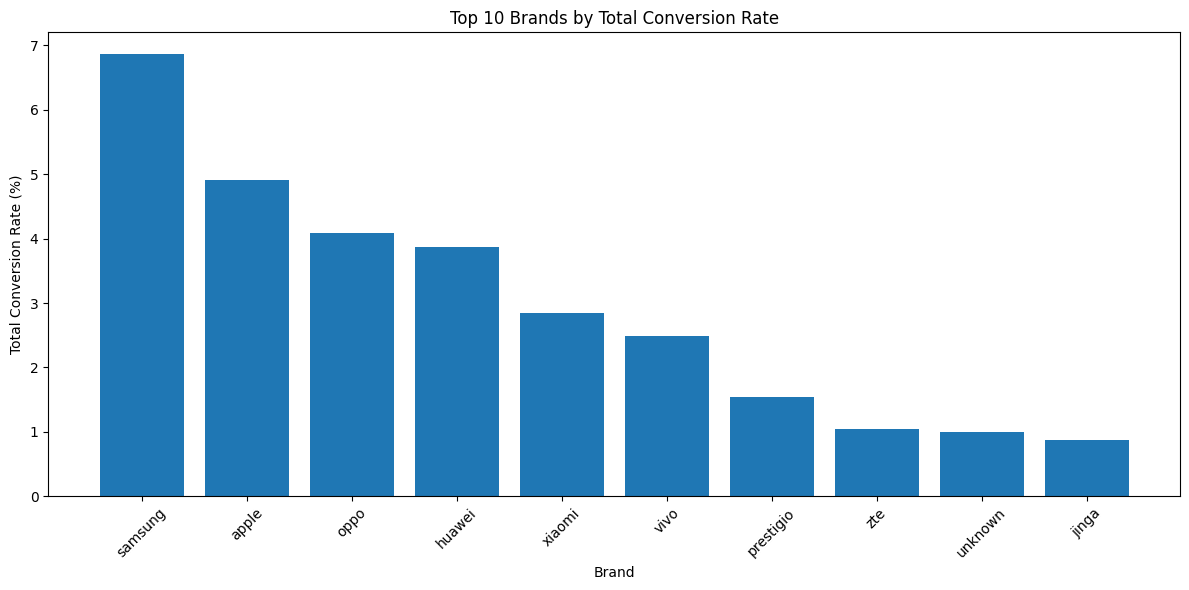

In [14]:
import matplotlib.pyplot as plt

top10_conv = brand_analysis.sort_values(
    by='total_conversion_rate', ascending=False
).head(10)

plt.figure(figsize=(12, 6))
plt.bar(top10_conv['brand'], top10_conv['total_conversion_rate'])
plt.xticks(rotation=45)
plt.title('Top 10 Brands by Total Conversion Rate')
plt.xlabel('Brand')
plt.ylabel('Total Conversion Rate (%)')
plt.tight_layout()
plt.show()

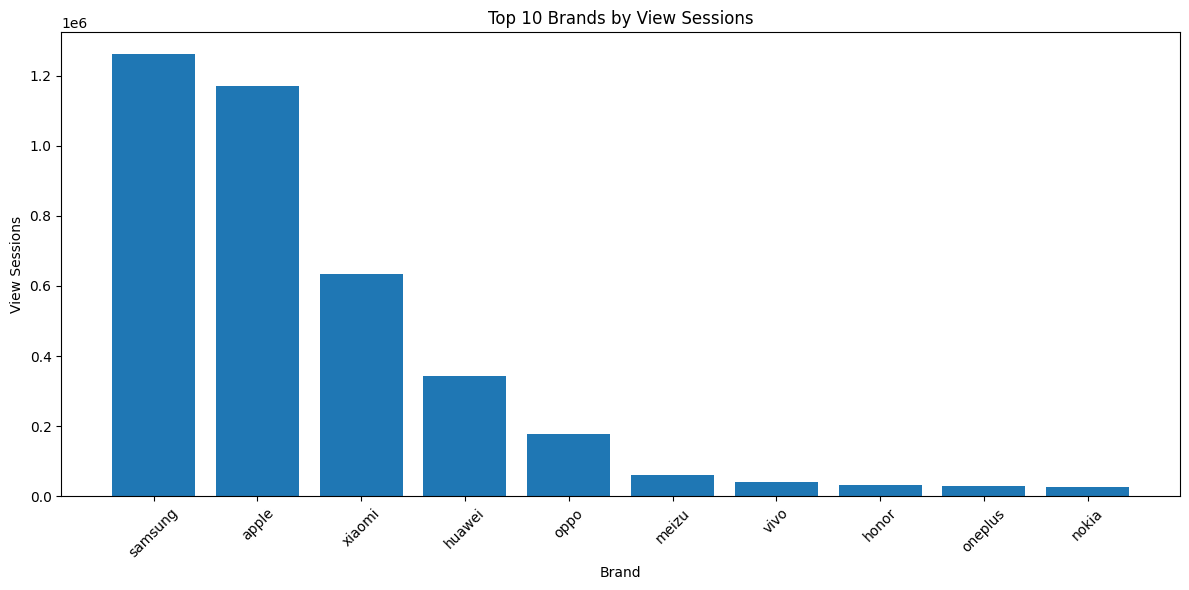

In [15]:
top10_view = brand_analysis.sort_values(
    by='view_sessions', ascending=False
).head(10)

plt.figure(figsize=(12, 6))
plt.bar(top10_view['brand'], top10_view['view_sessions'])
plt.xticks(rotation=45)
plt.title('Top 10 Brands by View Sessions')
plt.xlabel('Brand')
plt.ylabel('View Sessions')
plt.tight_layout()
plt.show()

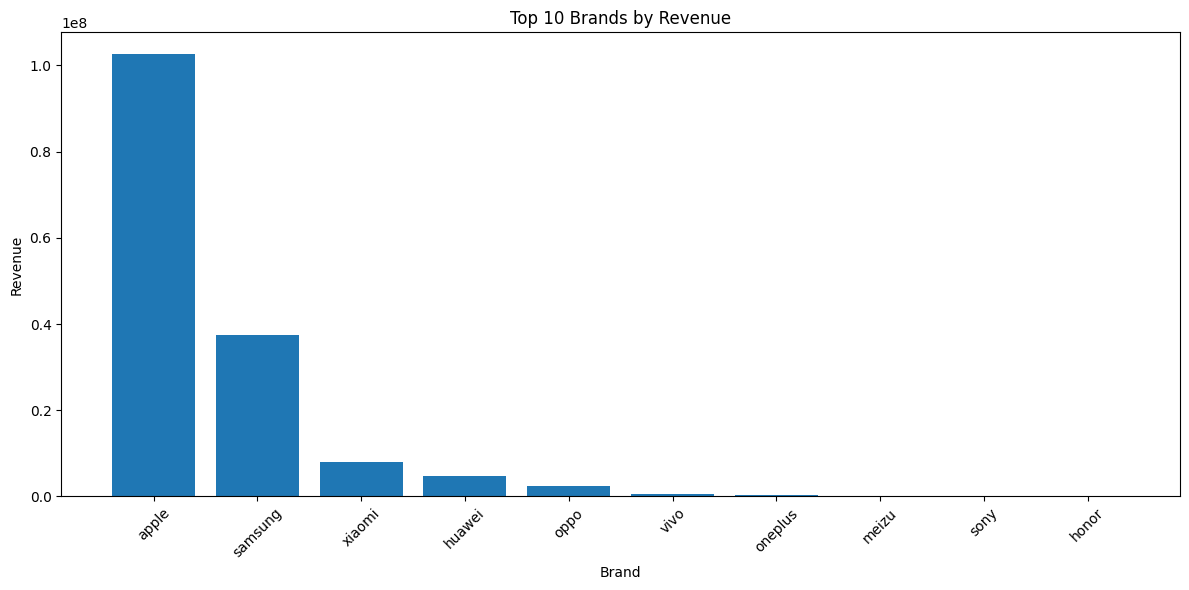

In [16]:
top10_revenue = brand_analysis.sort_values(
    by='revenue', ascending=False
).head(10)

plt.figure(figsize=(12, 6))
plt.bar(top10_revenue['brand'], top10_revenue['revenue'])
plt.xticks(rotation=45)
plt.title('Top 10 Brands by Revenue')
plt.xlabel('Brand')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

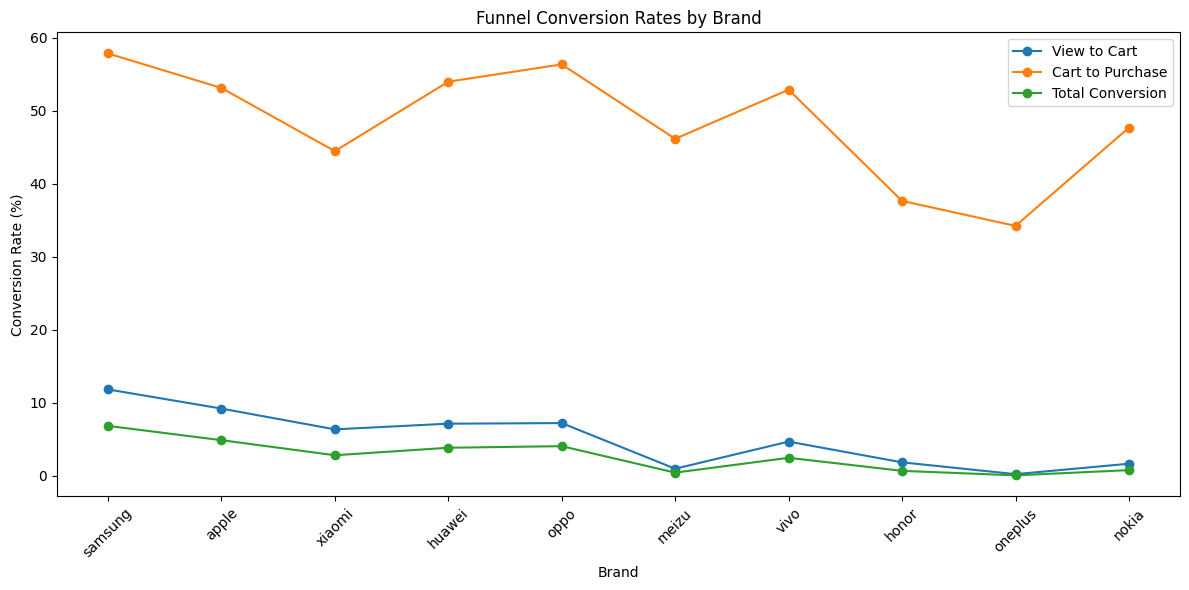

In [17]:
top10_funnel = brand_analysis.sort_values(
    by='view_sessions', ascending=False
).head(10)

x = range(len(top10_funnel))

plt.figure(figsize=(12, 6))
plt.plot(x, top10_funnel['view_to_cart_rate'], marker='o', label='View to Cart')
plt.plot(x, top10_funnel['cart_to_purchase_rate'], marker='o', label='Cart to Purchase')
plt.plot(x, top10_funnel['total_conversion_rate'], marker='o', label='Total Conversion')

plt.xticks(x, top10_funnel['brand'], rotation=45)
plt.title('Funnel Conversion Rates by Brand')
plt.xlabel('Brand')
plt.ylabel('Conversion Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

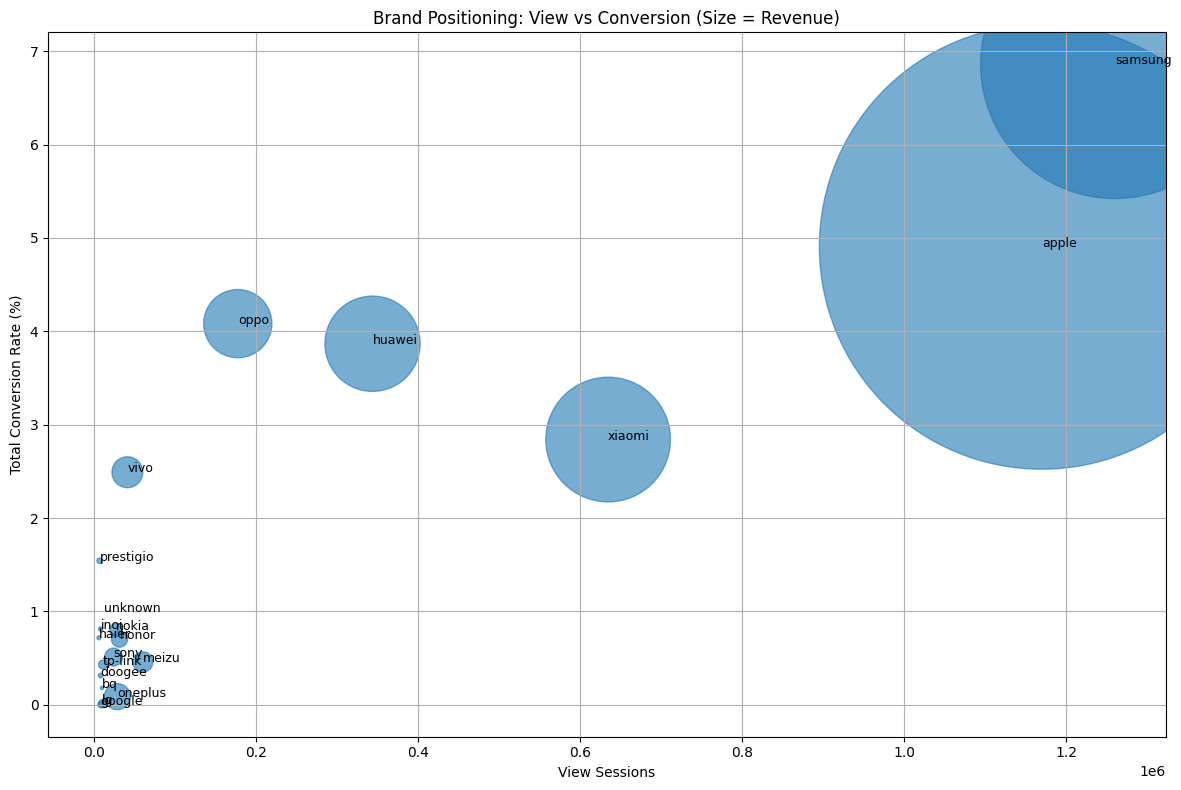

In [18]:
import matplotlib.pyplot as plt

# 상위 브랜드만 (노이즈 제거)
plot_df = brand_analysis.sort_values(
    by='view_sessions', ascending=False
).head(20).copy()

plt.figure(figsize=(12, 8))

plt.scatter(
    plot_df['view_sessions'],                 # X축: 조회 수
    plot_df['total_conversion_rate'],        # Y축: 전환율
    s=plot_df['revenue'] / 1000,             # 점 크기: 매출 (스케일 조정)
    alpha=0.6
)

# 브랜드 이름 표시
for i, row in plot_df.iterrows():
    plt.text(
        row['view_sessions'],
        row['total_conversion_rate'],
        row['brand'],
        fontsize=9
    )

plt.xlabel('View Sessions')
plt.ylabel('Total Conversion Rate (%)')
plt.title('Brand Positioning: View vs Conversion (Size = Revenue)')
plt.grid(True)
plt.tight_layout()
plt.show()

x축 -> view 
y축 -> 구매율
점 크기 -> revenue

-삼성
조회 많고 전환율 높으며 매출(단가x)도 크다 -> 시장 지배형 브랜드 (대중성+효율)

-애플
조회 많고 전환율 높으며 매출(단가x)이 압도적 -> 프리미엄 수익형 브랜드 (고가 전략..?)

-샤오미
조회 많으나 전환율 낮음 -> 관심 대비 성과 낮은 브랜드 (구매 전환 실패)

“브랜드에 따라 구매 결정 구조가 다르다” (유저 행동을 확인해야함)

애플 → 신뢰 기반 구매
삼성 → 대중형 구매
샤오미 → 탐색형 소비

3종 브랜드 비교 근거로 제시..?

In [19]:
target_brands = ['apple', 'samsung', 'xiaomi']

compare_df = brand_analysis[
    brand_analysis['brand'].str.lower().isin(target_brands)
].copy()

compare_df

,brand,view_sessions,view_to_cart_sessions,cart_to_purchase_sessions,view_to_cart_rate,cart_to_purchase_rate,total_conversion_rate,drop_view_to_cart,drop_cart_to_purchase,revenue,purchase_count,avg_price
27,samsung,1260159,149394,86443,11.855171,57.862431,6.859690,88.144829,42.137569,3.737366e+07,143123.0,261.129673
0,apple,1169945,108004,57385,9.231545,53.132291,4.904931,90.768455,46.867709,1.025490e+08,115345.0,889.063293
36,xiaomi,634709,40529,18029,6.385446,44.484197,2.840514,93.614554,55.515803,8.059770e+06,38776.0,207.854606


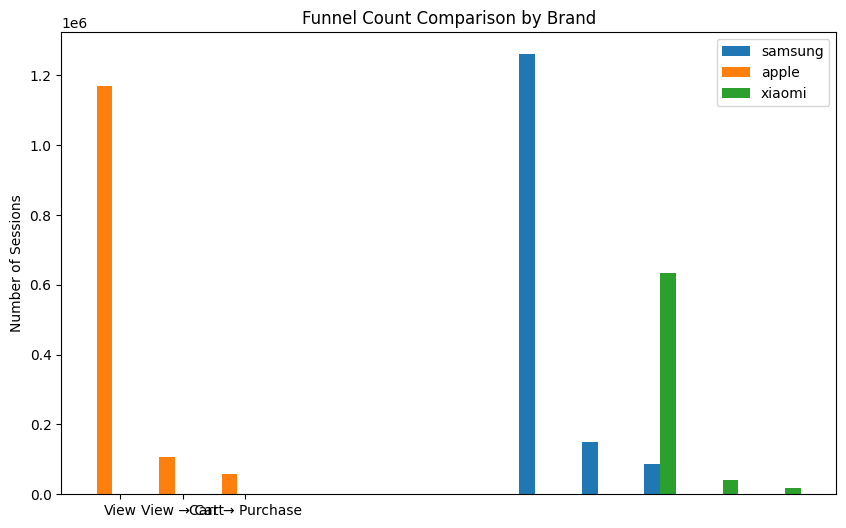

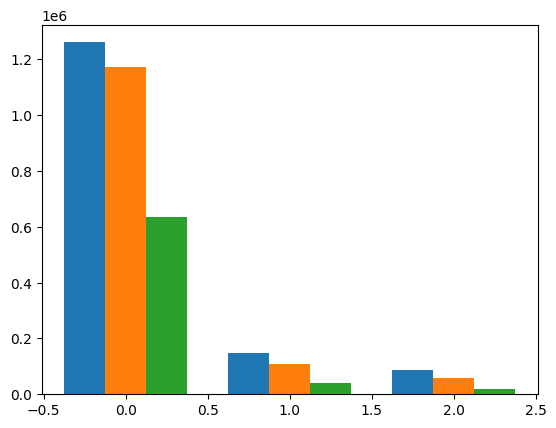

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# 퍼널 단계
stages = ['View', 'View → Cart', 'Cart → Purchase']
x = np.arange(len(stages))
width = 0.25

plt.figure(figsize=(10,6))

for i, row in compare_df.iterrows():
    values = [
        row['view_sessions'],
        row['view_to_cart_sessions'],
        row['cart_to_purchase_sessions']
    ]
    
    plt.bar(x + i*width, values, width, label=row['brand'])

# x축 위치 가운데 정렬
plt.xticks(x + width, stages)

plt.ylabel('Number of Sessions')
plt.title('Funnel Count Comparison by Brand')
plt.legend()
plt.show()
for i, row in enumerate(compare_df.itertuples()):
    values = [
        row.view_sessions,
        row.view_to_cart_sessions,
        row.cart_to_purchase_sessions
    ]
    plt.bar(x + (i-1)*width, values, width, label=row.brand)

1. 브랜드별 퍼널 분해 결과

분석의 활용 목적은 브랜드 성과 비교, 브랜드별 구매 전환력, 브랜드 내 대체 선택, 시장 구조 파악
"브랜드마다 다르다"가 아니라, "브랜드마다 맡는 역할이 다르고, 병목 구간도 다르다"

2. 브랜드별 평균/중앙 판매가
3. 상위 매출 product_id 비중
4. 세션당 조회 상품 수
5. 동일 세션 내 모델 비교 깊이

In [21]:
target_brands = ['apple', 'samsung', 'xiaomi']

df_target = df[df['brand'].str.lower().isin(target_brands)].copy()

-------------

#2 브랜드별 평균 / 중앙 판매가

In [22]:
#2 브랜드별 평균 / 중앙 판매가
brand_price_detail = (
    df_target[df_target['event_type'] == 'purchase']
    .groupby('brand')
    .agg(
        purchase_count=('price', 'count'),
        avg_price=('price', 'mean'),
        median_price=('price', 'median'),
        min_price=('price', 'min'),
        max_price=('price', 'max')
    )
    .reset_index()
)

brand_price_detail

,brand,purchase_count,avg_price,median_price,min_price,max_price
0,apple,115345,889.063293,808.70,358.18,2110.45
1,samsung,143123,261.129673,223.97,77.14,1544.42
2,xiaomi,38776,207.854606,190.22,74.13,609.83


여러개 구매한 케이스 잡아내지 못하나..?

-------------

#3. 상위 매출 product_id 비중

In [ ]:
#3. 상위 매출 product_id 비중
#몇 개 주력 모델에 몰려 있는지
product_revenue = (
    df_target[df_target['event_type'] == 'purchase']
    .groupby(['brand', 'product_id'])
    .agg(
        revenue=('price', 'sum'),
        purchase_count=('price', 'count')
    )
    .reset_index()
)

product_revenue

,brand,product_id,revenue,purchase_count
0,apple,1002522,5421.54,6
1,apple,1002524,3538299.12,6633
2,apple,1002525,31701.64,44
3,apple,1002527,2161.44,3
4,apple,1002528,354570.05,612
...,...,...,...,...
475,xiaomi,1005254,4946.13,11
476,xiaomi,1005256,6675.62,45
477,xiaomi,1005264,820.23,4
478,xiaomi,1005265,1635.80,8


In [ ]:
#상위 1개 / 3개 / 5개 상품 비중
def top_n_share(group, n):
    return group.sort_values('revenue', ascending=False).head(n)['revenue'].sum() / group['revenue'].sum()

top_share_rows = []

for brand, group in product_revenue.groupby('brand'):
    top_share_rows.append({
        'brand': brand,
        'top1_revenue_share': top_n_share(group, 1),
        'top3_revenue_share': top_n_share(group, 3),
        'top5_revenue_share': top_n_share(group, 5)
    })

top_share_df = pd.DataFrame(top_share_rows)
top_share_df

,brand,top1_revenue_share,top3_revenue_share,top5_revenue_share
0,apple,0.120984,0.286460,0.388104
1,samsung,0.145309,0.327952,0.447119
2,xiaomi,0.124597,0.292950,0.372212


In [42]:
top5_products = (
    product_revenue
    .sort_values(['brand', 'revenue'], ascending=[True, False])
    .groupby('brand')
    .head(5)
)

top5_products

,brand,product_id,revenue,purchase_count
114,apple,1005115,12406807.35,12543
104,apple,1005105,10239248.68,7293
74,apple,1004249,6730112.92,9090
134,apple,1005135,5567806.64,3218
14,apple,1002544,4855702.39,10549
240,samsung,1004767,5430723.43,21806
246,samsung,1004856,3798956.42,28944
250,samsung,1004870,3027098.05,10615
253,samsung,1004873,2269184.63,6053
242,samsung,1004833,2184501.96,12697


-----------------------

#4. 세션당 조회 상품 수

In [26]:
views_target = df_target[df_target['event_type'] == 'view'].copy()

session_view_depth = (
    views_target.groupby(['brand', 'user_session'])
    .agg(
        view_event_count=('product_id', 'size'),
        unique_view_products=('product_id', 'nunique')
    )
    .reset_index()
)

session_view_depth.head()

,brand,user_session,view_event_count,unique_view_products
0,apple,00000056-a206-40dd-b174-a072550fa38c,5,4
1,apple,00000083-8816-4d58-a9b8-f52f54186edc,5,5
2,apple,00000e03-279f-4a23-acb4-40d06b576299,3,2
3,apple,000013ec-1d9d-4ff8-8aef-fafa8cdbba11,1,1
4,apple,00001e73-384e-4c32-b677-8809d29320e6,5,2


In [27]:
brand_session_view_depth = (
    session_view_depth.groupby('brand')
    .agg(
        avg_view_events_per_session=('view_event_count', 'mean'),
        median_view_events_per_session=('view_event_count', 'median'),
        avg_unique_products_per_session=('unique_view_products', 'mean'),
        median_unique_products_per_session=('unique_view_products', 'median')
    )
    .reset_index()
)

brand_session_view_depth

,brand,avg_view_events_per_session,median_view_events_per_session,avg_unique_products_per_session,median_unique_products_per_session
0,apple,2.557190,2.0,1.855705,1.0
1,samsung,2.687654,2.0,1.783170,1.0
2,xiaomi,3.299518,2.0,1.979118,1.0


-----------------

#5. 동일 세션 내 모델 비교 깊이

In [43]:
brand_session_compare = (
    views_target.groupby(['brand', 'user_session'])
    .agg(
        unique_models_compared=('product_id', 'nunique')
    )
    .reset_index()
)

brand_session_compare.head()

,brand,user_session,unique_models_compared
0,apple,00000056-a206-40dd-b174-a072550fa38c,4
1,apple,00000083-8816-4d58-a9b8-f52f54186edc,5
2,apple,00000e03-279f-4a23-acb4-40d06b576299,2
3,apple,000013ec-1d9d-4ff8-8aef-fafa8cdbba11,1
4,apple,00001e73-384e-4c32-b677-8809d29320e6,2


In [44]:
brand_compare_depth = (
    brand_session_compare.groupby('brand')
    .agg(
        avg_model_compare_depth=('unique_models_compared', 'mean'),
        median_model_compare_depth=('unique_models_compared', 'median'),
        max_model_compare_depth=('unique_models_compared', 'max')
    )
    .reset_index()
)

brand_compare_depth

,brand,avg_model_compare_depth,median_model_compare_depth,max_model_compare_depth
0,apple,1.855705,1.0,54
1,samsung,1.783170,1.0,42
2,xiaomi,1.979118,1.0,70


In [45]:
compare_ratio = (
    brand_session_compare.groupby('brand')
    .apply(lambda g: pd.Series({
        'compare_2plus_session_ratio': (g['unique_models_compared'] >= 2).mean(),
        'compare_3plus_session_ratio': (g['unique_models_compared'] >= 3).mean()
    }))
    .reset_index()
)

compare_ratio

,brand,compare_2plus_session_ratio,compare_3plus_session_ratio
0,apple,0.383341,0.192478
1,samsung,0.338277,0.172141
2,xiaomi,0.383962,0.208565


In [48]:
brand_compare_depth = brand_compare_depth.merge(
    compare_ratio,
    on='brand',
    how='left'
)

brand_compare_depth

,brand,avg_model_compare_depth,median_model_compare_depth,max_model_compare_depth,compare_2plus_session_ratio,compare_3plus_session_ratio
0,apple,1.855705,1.0,54,0.383341,0.192478
1,samsung,1.783170,1.0,42,0.338277,0.172141
2,xiaomi,1.979118,1.0,70,0.383962,0.208565


-----------------

최종 요약

In [49]:
final_compare = (
    compare_df
    .merge(
        brand_price_detail[['brand', 'median_price', 'min_price', 'max_price']],
        on='brand',
        how='left'
    )
    .merge(top_share_df, on='brand', how='left')
    .merge(brand_session_view_depth, on='brand', how='left')
    .merge(brand_compare_depth, on='brand', how='left')
)

final_compare

,brand,view_sessions,view_to_cart_sessions,cart_to_purchase_sessions,view_to_cart_rate,cart_to_purchase_rate,total_conversion_rate,drop_view_to_cart,drop_cart_to_purchase,revenue,...,top5_revenue_share,avg_view_events_per_session,median_view_events_per_session,avg_unique_products_per_session,median_unique_products_per_session,avg_model_compare_depth,median_model_compare_depth,max_model_compare_depth,compare_2plus_session_ratio,compare_3plus_session_ratio
0,samsung,1260159,149394,86443,11.855171,57.862431,6.859690,88.144829,42.137569,3.737366e+07,...,0.447119,2.687654,2.0,1.783170,1.0,1.783170,1.0,42,0.338277,0.172141
1,apple,1169945,108004,57385,9.231545,53.132291,4.904931,90.768455,46.867709,1.025490e+08,...,0.388104,2.557190,2.0,1.855705,1.0,1.855705,1.0,54,0.383341,0.192478
2,xiaomi,634709,40529,18029,6.385446,44.484197,2.840514,93.614554,55.515803,8.059770e+06,...,0.372212,3.299518,2.0,1.979118,1.0,1.979118,1.0,70,0.383962,0.208565


In [50]:
pct_cols = [
    'top1_revenue_share',
    'top3_revenue_share',
    'top5_revenue_share',
    'compare_2plus_session_ratio',
    'compare_3plus_session_ratio'
]

final_compare[pct_cols] = final_compare[pct_cols] * 100

final_compare

,brand,view_sessions,view_to_cart_sessions,cart_to_purchase_sessions,view_to_cart_rate,cart_to_purchase_rate,total_conversion_rate,drop_view_to_cart,drop_cart_to_purchase,revenue,...,top5_revenue_share,avg_view_events_per_session,median_view_events_per_session,avg_unique_products_per_session,median_unique_products_per_session,avg_model_compare_depth,median_model_compare_depth,max_model_compare_depth,compare_2plus_session_ratio,compare_3plus_session_ratio
0,samsung,1260159,149394,86443,11.855171,57.862431,6.859690,88.144829,42.137569,3.737366e+07,...,44.711873,2.687654,2.0,1.783170,1.0,1.783170,1.0,42,33.827715,17.214098
1,apple,1169945,108004,57385,9.231545,53.132291,4.904931,90.768455,46.867709,1.025490e+08,...,38.810399,2.557190,2.0,1.855705,1.0,1.855705,1.0,54,38.334110,19.247828
2,xiaomi,634709,40529,18029,6.385446,44.484197,2.840514,93.614554,55.515803,8.059770e+06,...,37.221177,3.299518,2.0,1.979118,1.0,1.979118,1.0,70,38.396178,20.856487


시각화

In [51]:
import matplotlib.pyplot as plt
import numpy as np

brand_order = ['samsung', 'apple', 'xiaomi']

plot_df = final_compare.copy()
plot_df['brand'] = pd.Categorical(plot_df['brand'], categories=brand_order, ordered=True)
plot_df = plot_df.sort_values('brand')
plot_df

,brand,view_sessions,view_to_cart_sessions,cart_to_purchase_sessions,view_to_cart_rate,cart_to_purchase_rate,total_conversion_rate,drop_view_to_cart,drop_cart_to_purchase,revenue,...,top5_revenue_share,avg_view_events_per_session,median_view_events_per_session,avg_unique_products_per_session,median_unique_products_per_session,avg_model_compare_depth,median_model_compare_depth,max_model_compare_depth,compare_2plus_session_ratio,compare_3plus_session_ratio
0,samsung,1260159,149394,86443,11.855171,57.862431,6.859690,88.144829,42.137569,3.737366e+07,...,44.711873,2.687654,2.0,1.783170,1.0,1.783170,1.0,42,33.827715,17.214098
1,apple,1169945,108004,57385,9.231545,53.132291,4.904931,90.768455,46.867709,1.025490e+08,...,38.810399,2.557190,2.0,1.855705,1.0,1.855705,1.0,54,38.334110,19.247828
2,xiaomi,634709,40529,18029,6.385446,44.484197,2.840514,93.614554,55.515803,8.059770e+06,...,37.221177,3.299518,2.0,1.979118,1.0,1.979118,1.0,70,38.396178,20.856487


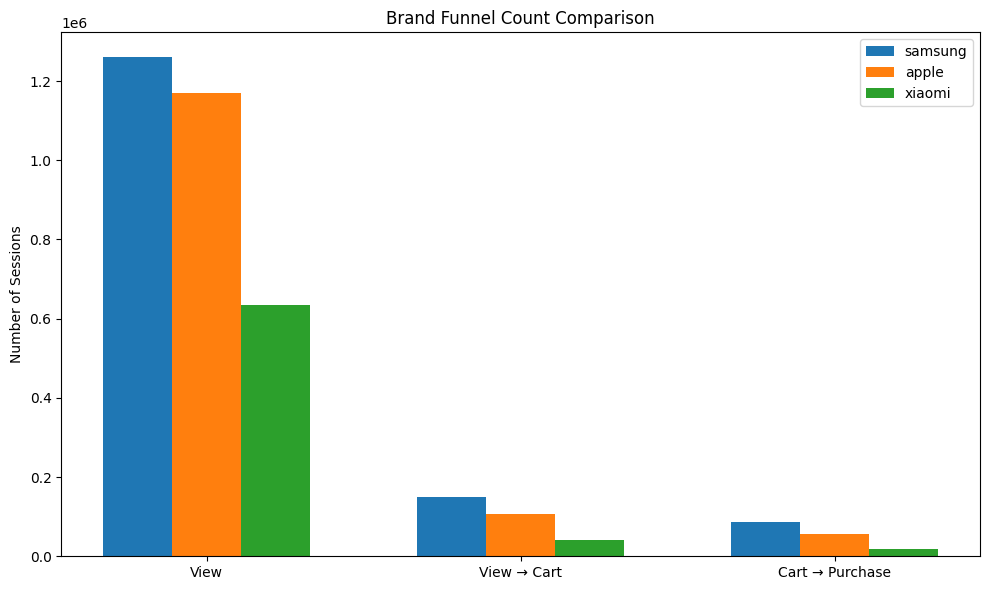

In [36]:
stages = ['View', 'View → Cart', 'Cart → Purchase']
x = np.arange(len(stages))
width = 0.22

plt.figure(figsize=(10, 6))

for i, row in enumerate(plot_df.itertuples()):
    values = [
        row.view_sessions,
        row.view_to_cart_sessions,
        row.cart_to_purchase_sessions
    ]
    plt.bar(x + (i - 1) * width, values, width, label=row.brand)

plt.xticks(x, stages)
plt.ylabel('Number of Sessions')
plt.title('Brand Funnel Count Comparison')
plt.legend()
plt.tight_layout()
plt.show()

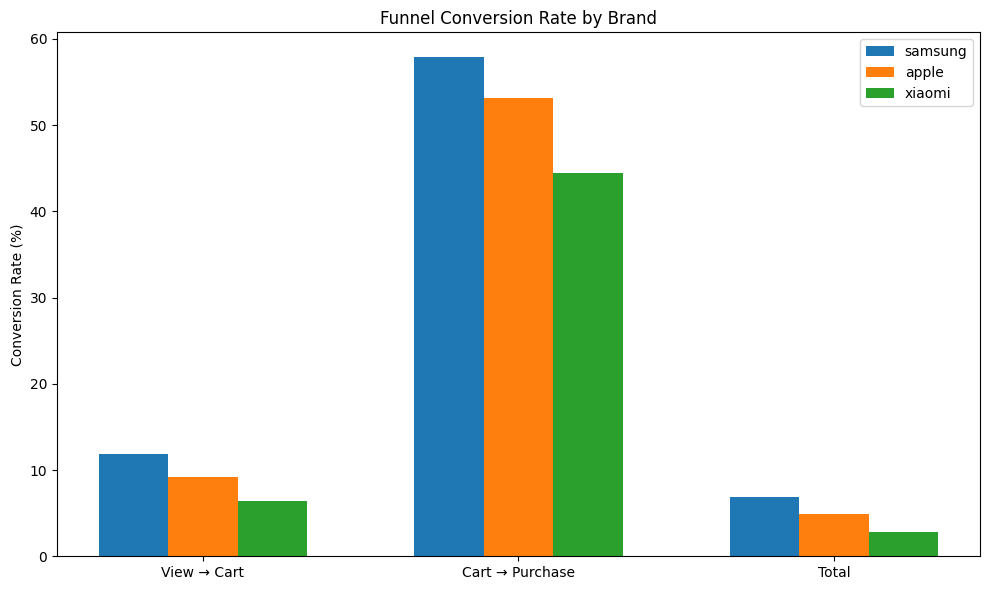

In [41]:
rate_cols = ['view_to_cart_rate', 'cart_to_purchase_rate', 'total_conversion_rate']
rate_labels = ['View → Cart', 'Cart → Purchase', 'Total']

x = np.arange(len(rate_labels))
width = 0.22

plt.figure(figsize=(10, 6))

for i, row in enumerate(plot_df.itertuples()):
    values = [row.view_to_cart_rate, row.cart_to_purchase_rate, row.total_conversion_rate]
    plt.bar(x + (i - 1) * width, values, width, label=row.brand)

plt.xticks(x, rate_labels)
plt.ylabel('Conversion Rate (%)')
plt.title('Funnel Conversion Rate by Brand')
plt.legend()
plt.tight_layout()
plt.show()

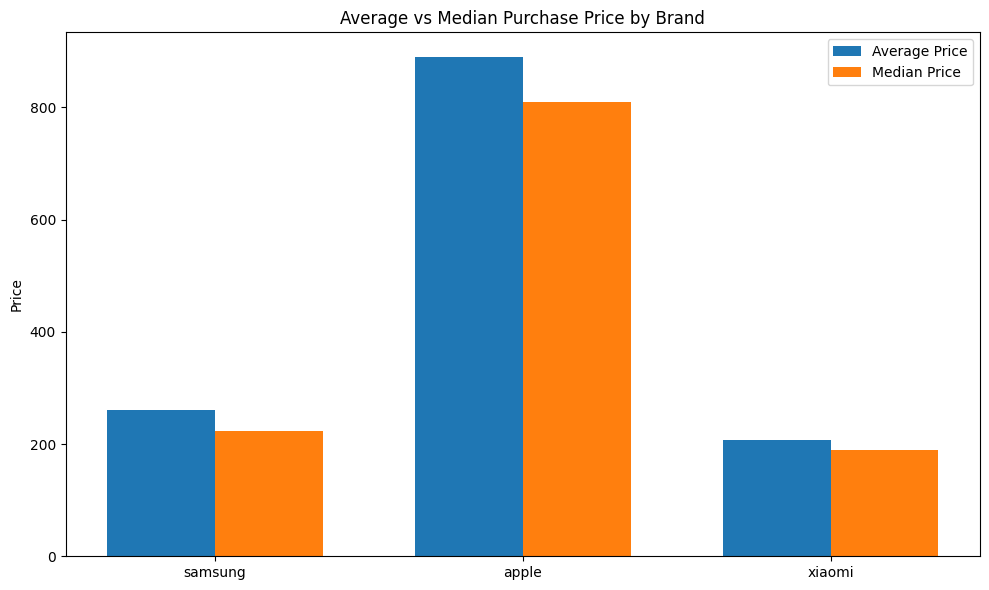

In [37]:
x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, plot_df['avg_price'], width, label='Average Price')
plt.bar(x + width/2, plot_df['median_price'], width, label='Median Price')

plt.xticks(x, plot_df['brand'])
plt.ylabel('Price')
plt.title('Average vs Median Purchase Price by Brand')
plt.legend()
plt.tight_layout()
plt.show()

price에 대한 논의 필요

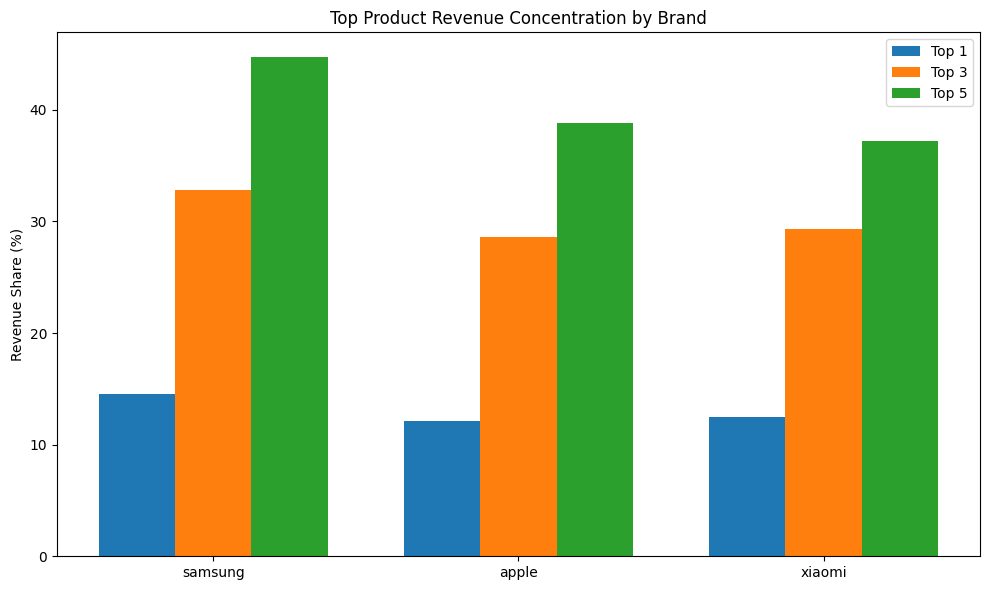

In [38]:
x = np.arange(len(plot_df))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, plot_df['top1_revenue_share'], width, label='Top 1')
plt.bar(x, plot_df['top3_revenue_share'], width, label='Top 3')
plt.bar(x + width, plot_df['top5_revenue_share'], width, label='Top 5')

plt.xticks(x, plot_df['brand'])
plt.ylabel('Revenue Share (%)')
plt.title('Top Product Revenue Concentration by Brand')
plt.legend()
plt.tight_layout()
plt.show()

비중이 클수록 주력 모델 중심의 소비

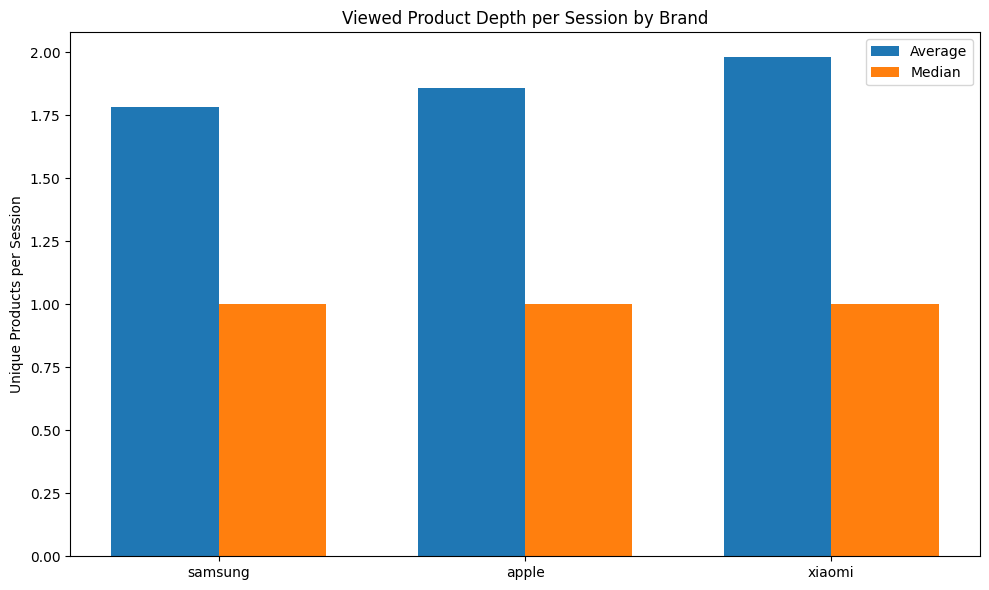

In [ ]:
#세션 당 조회 상품 수
x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, plot_df['avg_unique_products_per_session'], width, label='Average')
plt.bar(x + width/2, plot_df['median_unique_products_per_session'], width, label='Median')

plt.xticks(x, plot_df['brand'])
plt.ylabel('Unique Products per Session')
plt.title('Viewed Product Depth per Session by Brand')
plt.legend()
plt.tight_layout()
plt.show()

삼성은 규모와 효율을 동시에 확보한 시장 지배형 브랜드,
애플은 높은 매출을 만드는 프리미엄 수익형 브랜드,
샤오미는 탐색은 많지만 전환이 낮은 비교형 브랜드

삼성
view_to_cart: 11.85% (최고)
total conversion: 6.86% (최고)

애플
view_to_cart: 9.23%
total conversion: 4.90%
매출: 1억 이상 (압도적)

샤오미
view_to_cart: 6.38% (최저)
total conversion: 2.84% (최저)
drop_view_to_cart: 93.6% (최악)

상품 구조 (top5 비중)
삼성: 44.7%
애플: 38.8%
샤오미: 37.2%

삼성은 특정 모델 의존도가 더 높음

탐색 행동
세션당 조회 수
샤오미: 3.29 (최고)
삼성: 2.68
애플: 2.55

샤오미 = 가장 많이 둘러봄

애플 = drop_cart_to_purchase: 46.8%
결제 직전에서 일부 이탈

시장 구조 핵심 인사이트
조회가 많다고 구매가 많은 건 아니다 → 샤오미 사례
매출은 전환율보다 가격의 영향을 더 크게 받는다→ 애플 사례
브랜드마다 소비자 행동 구조 자체가 다르다
→ 탐색형 vs 충성형 vs 대중형

“브랜드는 단순히 제품이 아니라 소비자의 행동을 바꾼다”